# Lumora X-ray and CT Model Evaluation

This notebook runs both trained Lumora models and shows their accuracy side by side with tables, bar charts, and matrix-style heatmaps.

## 1. Setup

Change the limits if you want a faster or fuller evaluation. `None` means evaluate every locally available sample for that modality.

In [1]:
from pathlib import Path
from types import SimpleNamespace
import ast
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader, Subset
from transformers import AutoTokenizer

from evaluate_final_model_accuracy import (
    DEFAULT_CT_DATA_DIR,
    DEFAULT_CT_MODEL_PATH,
    DEFAULT_XRAY_IMG_ROOT,
    DEFAULT_XRAY_MODEL_PATH,
    DEFAULT_XRAY_VALID_CSV,
    MAX_TEXT_LENGTH,
    build_ct_dataset,
    build_xray_dataset,
    evaluate,
    get_device,
    load_model,
)

XRAY_LIMIT = None  # local X-ray validation currently has 338 usable rows
CT_LIMIT = None    # CT validation currently has 1 locally downloaded row
BATCH_SIZE = 1
MAX_LEN = MAX_TEXT_LENGTH
NUM_WORKERS = 0

XRAY_MODEL_PATH = DEFAULT_XRAY_MODEL_PATH
XRAY_TRAIN_CSV = Path('mimic_cxr_aug_train.csv')
XRAY_VALID_CSV = DEFAULT_XRAY_VALID_CSV
XRAY_IMG_ROOT = DEFAULT_XRAY_IMG_ROOT

CT_MODEL_PATH = DEFAULT_CT_MODEL_PATH
CT_DATA_DIR = DEFAULT_CT_DATA_DIR
CT_VALID_CSV = None

device = get_device()
print(f'Device: {device}')

Device: mps


## 2. Dataset Description

This section uses the same dataset files as the training notebooks: MIMIC-CXR image/report CSVs for the X-ray model and CT-RATE report CSVs plus local NIfTI volumes for the CT model.

In [2]:
def word_count(text):
    return len(str(text).split())


def read_xray_csv(path):
    df = pd.read_csv(path)
    df['image_list'] = df['image'].apply(ast.literal_eval)
    df['text_list'] = df['text'].apply(ast.literal_eval)
    df['image_count'] = df['image_list'].apply(len)
    df['report_text'] = df['text_list'].apply(lambda values: values[0] if values else '')
    df['report_words'] = df['report_text'].apply(word_count)
    df['has_local_image'] = df['image_list'].apply(
        lambda paths: any((XRAY_IMG_ROOT / path).exists() for path in paths)
    )
    return df


def read_ct_report_csv(split):
    filename = 'train_reports.csv' if split == 'train' else 'validation_reports.csv'
    path = CT_DATA_DIR / 'dataset' / 'radiology_text_reports' / filename
    df = pd.read_csv(path)
    df['split'] = split
    df['report_text'] = (
        df.get('Findings_EN', '').fillna('').astype(str)
        + ' '
        + df.get('Impressions_EN', '').fillna('').astype(str)
    ).str.strip()
    df['report_words'] = df['report_text'].apply(word_count)
    return df


xray_train_df = read_xray_csv(XRAY_TRAIN_CSV)
xray_valid_df = read_xray_csv(XRAY_VALID_CSV)
ct_train_df = read_ct_report_csv('train')
ct_valid_df = read_ct_report_csv('valid')

ct_train_files = list((CT_DATA_DIR / 'dataset' / 'train_fixed').rglob('*.nii.gz'))
ct_valid_files = list((CT_DATA_DIR / 'dataset' / 'valid_fixed').rglob('*.nii.gz'))

dataset_description = pd.DataFrame(
    [
        {
            'Dataset': 'MIMIC-CXR X-ray',
            'Modality': '2D chest X-ray JPG',
            'Train CSV rows': len(xray_train_df),
            'Validation CSV rows': len(xray_valid_df),
            'Local validation rows': int(xray_valid_df['has_local_image'].sum()),
            'Local CT/scan files': np.nan,
            'Mean validation report words': xray_valid_df['report_words'].mean(),
        },
        {
            'Dataset': 'CT-RATE',
            'Modality': '3D chest CT NIfTI',
            'Train CSV rows': len(ct_train_df),
            'Validation CSV rows': len(ct_valid_df),
            'Local validation rows': len(ct_valid_files),
            'Local CT/scan files': len(ct_train_files) + len(ct_valid_files),
            'Mean validation report words': ct_valid_df['report_words'].mean(),
        },
    ]
)

display(dataset_description.style.format({'Mean validation report words': '{:.1f}'}))

,Dataset,Modality,Train CSV rows,Validation CSV rows,Local validation rows,Local CT/scan files,Mean validation report words
0,MIMIC-CXR X-ray,2D chest X-ray JPG,64586,500,338,nan,52.7
1,CT-RATE,3D chest CT NIfTI,47149,3039,1,65.000000,230.6


## 3. Data Split Summary

The split table compares full CSV availability with the subset that is actually present on this machine. This keeps the notebook aligned with the local training/evaluation setup.

In [3]:
split_df = pd.DataFrame(
    [
        {'Dataset': 'X-ray', 'Split': 'Train CSV', 'Rows': len(xray_train_df), 'Local usable': np.nan},
        {
            'Dataset': 'X-ray',
            'Split': 'Validation CSV',
            'Rows': len(xray_valid_df),
            'Local usable': int(xray_valid_df['has_local_image'].sum()),
        },
        {'Dataset': 'CT', 'Split': 'Train CSV', 'Rows': len(ct_train_df), 'Local usable': len(ct_train_files)},
        {'Dataset': 'CT', 'Split': 'Validation CSV', 'Rows': len(ct_valid_df), 'Local usable': len(ct_valid_files)},
    ]
)

display(split_df.style.format({'Rows': '{:,.0f}', 'Local usable': '{:,.0f}'}))

,Dataset,Split,Rows,Local usable
0,X-ray,Train CSV,"64,586",nan
1,X-ray,Validation CSV,500,338
2,CT,Train CSV,"47,149",64
3,CT,Validation CSV,"3,039",1


## 4. Data Analysis Graphs

These figures summarize the same data splits used by the training notebooks and the evaluation script.

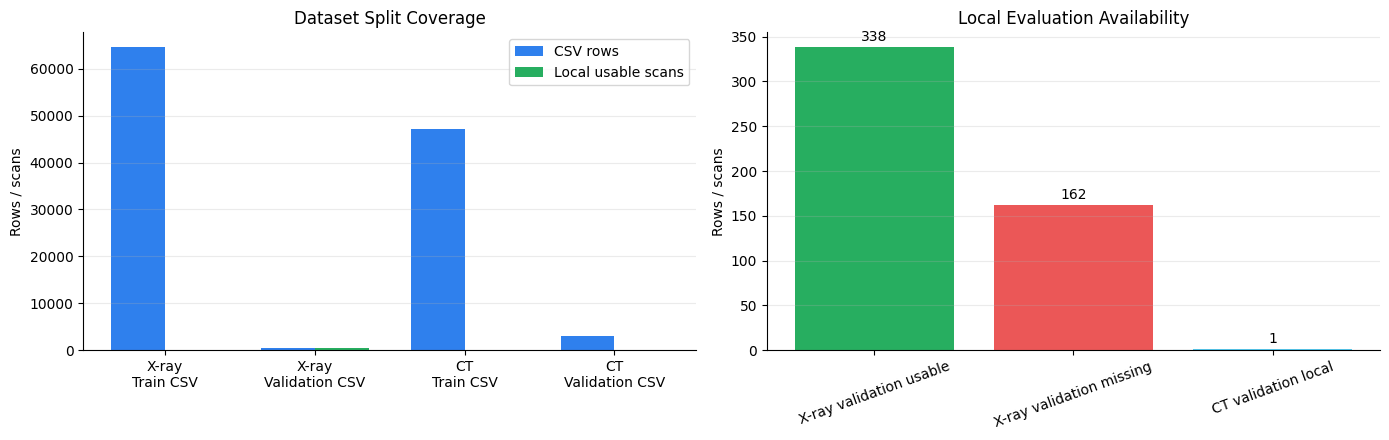

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

split_plot = split_df.copy()
x = np.arange(len(split_plot))
axes[0].bar(x - 0.18, split_plot['Rows'], width=0.36, label='CSV rows', color='#2f80ed')
axes[0].bar(
    x + 0.18,
    split_plot['Local usable'].fillna(0),
    width=0.36,
    label='Local usable scans',
    color='#27ae60',
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(split_plot['Dataset'] + '\n' + split_plot['Split'], rotation=0)
axes[0].set_title('Dataset Split Coverage')
axes[0].set_ylabel('Rows / scans')
axes[0].legend()

coverage_counts = pd.Series(
    {
        'X-ray validation usable': int(xray_valid_df['has_local_image'].sum()),
        'X-ray validation missing': int((~xray_valid_df['has_local_image']).sum()),
        'CT validation local': len(ct_valid_files),
    }
)
axes[1].bar(coverage_counts.index, coverage_counts.values, color=['#27ae60', '#eb5757', '#56ccf2'])
axes[1].set_title('Local Evaluation Availability')
axes[1].set_ylabel('Rows / scans')
axes[1].tick_params(axis='x', rotation=20)
for idx, value in enumerate(coverage_counts.values):
    axes[1].text(idx, value + max(coverage_counts.values) * 0.02, f'{value:,}', ha='center')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

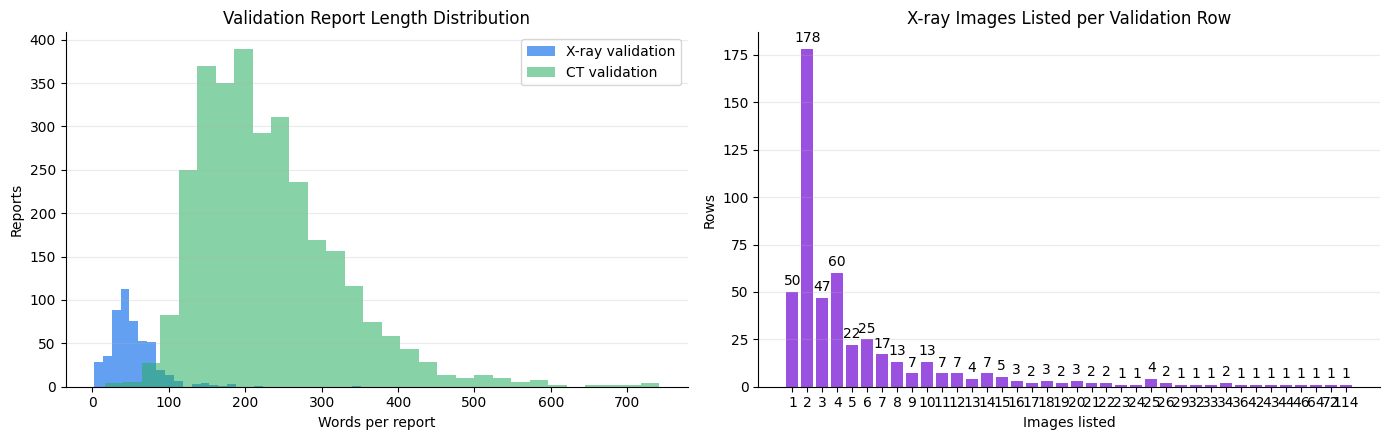

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(xray_valid_df['report_words'], bins=30, alpha=0.75, label='X-ray validation', color='#2f80ed')
axes[0].hist(ct_valid_df['report_words'], bins=30, alpha=0.55, label='CT validation', color='#27ae60')
axes[0].set_title('Validation Report Length Distribution')
axes[0].set_xlabel('Words per report')
axes[0].set_ylabel('Reports')
axes[0].legend()

image_count_counts = xray_valid_df['image_count'].value_counts().sort_index()
axes[1].bar(image_count_counts.index.astype(str), image_count_counts.values, color='#9b51e0')
axes[1].set_title('X-ray Images Listed per Validation Row')
axes[1].set_xlabel('Images listed')
axes[1].set_ylabel('Rows')
for idx, value in enumerate(image_count_counts.values):
    axes[1].text(idx, value + max(image_count_counts.values) * 0.02, f'{value:,}', ha='center')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

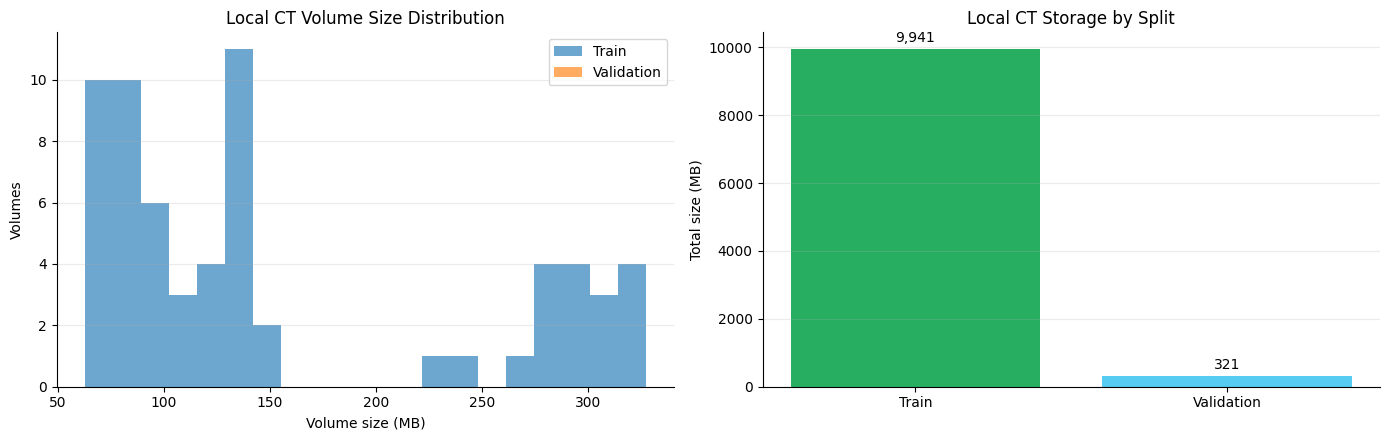

,count,mean,min,max,sum
Split,,,,,
Train,64.0,155.3,62.7,327.7,"9,941.4"
Validation,1.0,320.8,320.8,320.8,320.8


In [6]:
ct_file_df = pd.DataFrame(
    [
        {'Split': 'Train', 'Path': path, 'Size MB': path.stat().st_size / 1024**2}
        for path in ct_train_files
    ]
    + [
        {'Split': 'Validation', 'Path': path, 'Size MB': path.stat().st_size / 1024**2}
        for path in ct_valid_files
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

if not ct_file_df.empty:
    for split, group in ct_file_df.groupby('Split'):
        axes[0].hist(group['Size MB'], bins=20, alpha=0.65, label=split)
    axes[0].legend()
axes[0].set_title('Local CT Volume Size Distribution')
axes[0].set_xlabel('Volume size (MB)')
axes[0].set_ylabel('Volumes')

size_summary = ct_file_df.groupby('Split')['Size MB'].sum().sort_index() if not ct_file_df.empty else pd.Series(dtype=float)
axes[1].bar(size_summary.index, size_summary.values, color=['#27ae60', '#56ccf2'][: len(size_summary)])
axes[1].set_title('Local CT Storage by Split')
axes[1].set_ylabel('Total size (MB)')
for idx, value in enumerate(size_summary.values):
    axes[1].text(idx, value + max(size_summary.values) * 0.02, f'{value:,.0f}', ha='center')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

display(ct_file_df.groupby('Split')['Size MB'].agg(['count', 'mean', 'min', 'max', 'sum']).style.format('{:,.1f}'))

## 5. Shared Helpers

These cells split the script logic into notebook-friendly pieces: dataset creation, loader creation, model loading, and metric collection.

In [7]:
def make_args(modality, limit):
    return SimpleNamespace(
        modality=modality,
        xray_model_path=XRAY_MODEL_PATH,
        ct_model_path=CT_MODEL_PATH,
        xray_valid_csv=XRAY_VALID_CSV,
        ct_valid_csv=CT_VALID_CSV,
        xray_img_root=XRAY_IMG_ROOT,
        ct_data_dir=CT_DATA_DIR,
        batch_size=BATCH_SIZE,
        max_text_length=MAX_LEN,
        num_workers=NUM_WORKERS,
        limit=limit,
    )


def build_dataset_for_modality(modality, tokenizer, limit):
    args = make_args(modality, limit)
    if modality == 'xray':
        dataset = build_xray_dataset(args, tokenizer)
        print(
            f'X-ray usable rows: {len(dataset):,}; '
            f'skipped missing rows: {dataset.skipped_missing_images:,}'
        )
        if limit is not None:
            dataset = Subset(dataset, range(min(limit, len(dataset))))
        model_path = args.xray_model_path
    elif modality == 'ct':
        dataset = build_ct_dataset(args, tokenizer)
        print(f'CT usable rows: {len(dataset):,}')
        model_path = args.ct_model_path
    else:
        raise ValueError(f'Unknown modality: {modality}')

    loader = DataLoader(
        dataset,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=device.type == 'cuda',
    )
    return dataset, loader, Path(model_path)


def run_modality_evaluation(modality, tokenizer, limit):
    print('\n' + '=' * 72)
    print(f'Evaluating {modality.upper()} model')
    print('=' * 72)

    dataset, loader, model_path = build_dataset_for_modality(modality, tokenizer, limit)
    print(f'Model path: {model_path.resolve()}')
    print(f'Evaluation rows: {len(dataset):,}')

    model, checkpoint = load_model(model_path, device)
    saved_val_loss = None
    if isinstance(checkpoint, dict):
        saved_val_loss = checkpoint.get('final_val_loss', checkpoint.get('val_loss'))
        if saved_val_loss is not None:
            print(f'Saved checkpoint validation loss: {saved_val_loss}')

    metrics = evaluate(model, loader, device)
    metrics['rows_evaluated'] = len(dataset)
    metrics['saved_checkpoint_val_loss'] = saved_val_loss

    del model
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    return metrics

## 6. Run Both Evaluations

This is the main execution cell. It evaluates X-ray first, then CT, and stores both metric dictionaries.

In [8]:
tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

results = {
    'XRAY': run_modality_evaluation('xray', tokenizer, XRAY_LIMIT),
    'CT': run_modality_evaluation('ct', tokenizer, CT_LIMIT),
}

metrics_df = pd.DataFrame(results).T
metrics_df


Evaluating XRAY model
X-ray usable rows: 338; skipped missing rows: 162
Model path: /Users/md.nurealamsiddiquee/Projects/lumora/checkpoints/x_ray/mimic_vlm_phase2_fully_trained.pt
Evaluation rows: 338


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Saved checkpoint validation loss: 0.9270920507491581


Evaluating final model:   0%|          | 0/338 [00:00<?, ?it/s]


Evaluating CT model
CT validation CSV: /Users/md.nurealamsiddiquee/Projects/lumora/data/ct_rate/dataset/radiology_text_reports/validation_reports.csv
CT data dir: /Users/md.nurealamsiddiquee/Projects/lumora/data/ct_rate
CT usable rows: 1
Model path: /Users/md.nurealamsiddiquee/Projects/lumora/checkpoints/ct_rate/ct_rate_vlm_phase2_fully_trained.pt
Evaluation rows: 1


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Saved checkpoint validation loss: 1.6689003705978394


Evaluating final model:   0%|          | 0/1 [00:00<?, ?it/s]

,validation_loss,perplexity,token_accuracy,exact_sequence_accuracy,correct_tokens,total_tokens,exact_sequences,total_sequences,rows_evaluated,saved_checkpoint_val_loss
XRAY,0.9475,2.579255,0.775637,0.02071,21019.0,27099.0,7.0,338.0,338.0,0.927092
CT,1.6689,5.306330,0.724409,0.00000,92.0,127.0,0.0,1.0,1.0,1.668900


## 7. Accuracy Table

The table below shows the same metrics as the script, formatted for quick comparison.

In [9]:
summary_df = metrics_df[
    [
        'rows_evaluated',
        'validation_loss',
        'perplexity',
        'token_accuracy',
        'exact_sequence_accuracy',
        'correct_tokens',
        'total_tokens',
        'exact_sequences',
        'total_sequences',
    ]
].copy()

display(
    summary_df.style.format(
        {
            'rows_evaluated': '{:,.0f}',
            'validation_loss': '{:.4f}',
            'perplexity': '{:.4f}',
            'token_accuracy': '{:.2%}',
            'exact_sequence_accuracy': '{:.2%}',
            'correct_tokens': '{:,.0f}',
            'total_tokens': '{:,.0f}',
            'exact_sequences': '{:,.0f}',
            'total_sequences': '{:,.0f}',
        }
    )
)

,rows_evaluated,validation_loss,perplexity,token_accuracy,exact_sequence_accuracy,correct_tokens,total_tokens,exact_sequences,total_sequences
XRAY,338,0.9475,2.5793,77.56%,2.07%,"21,019","27,099",7,338
CT,1,1.6689,5.3063,72.44%,0.00%,92,127,0,1


## 8. Accuracy and Loss Graphs

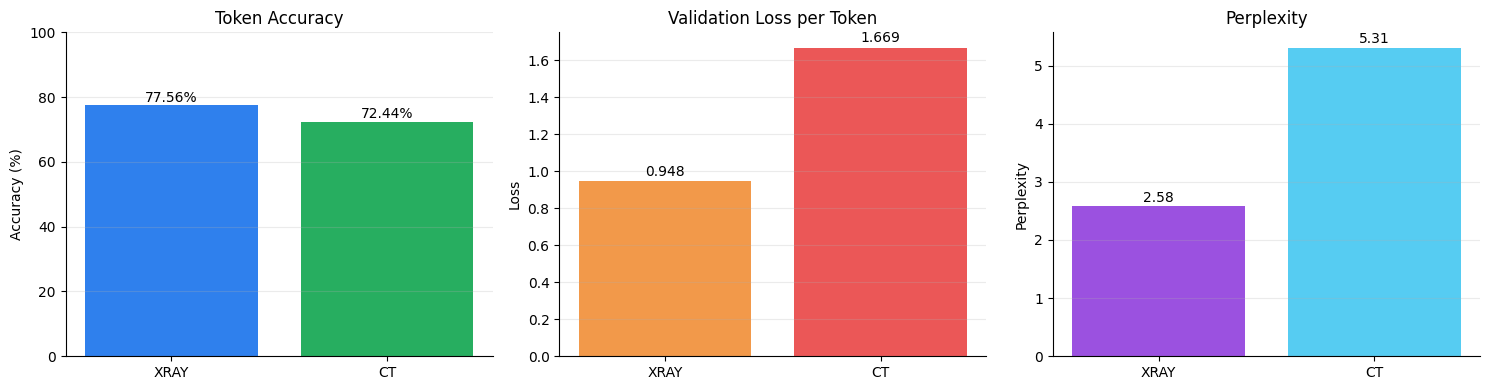

In [10]:
plot_df = summary_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(plot_df.index, plot_df['token_accuracy'] * 100, color=['#2f80ed', '#27ae60'])
axes[0].set_title('Token Accuracy')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
for idx, value in enumerate(plot_df['token_accuracy'] * 100):
    axes[0].text(idx, value + 1, f'{value:.2f}%', ha='center')

axes[1].bar(plot_df.index, plot_df['validation_loss'], color=['#f2994a', '#eb5757'])
axes[1].set_title('Validation Loss per Token')
axes[1].set_ylabel('Loss')
for idx, value in enumerate(plot_df['validation_loss']):
    axes[1].text(idx, value + 0.03, f'{value:.3f}', ha='center')

axes[2].bar(plot_df.index, plot_df['perplexity'], color=['#9b51e0', '#56ccf2'])
axes[2].set_title('Perplexity')
axes[2].set_ylabel('Perplexity')
for idx, value in enumerate(plot_df['perplexity']):
    axes[2].text(idx, value + 0.08, f'{value:.2f}', ha='center')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

## 9. Metric Matrix Figure

This heatmap is a compact matrix view of the two model outputs. Values are annotated directly in each cell.

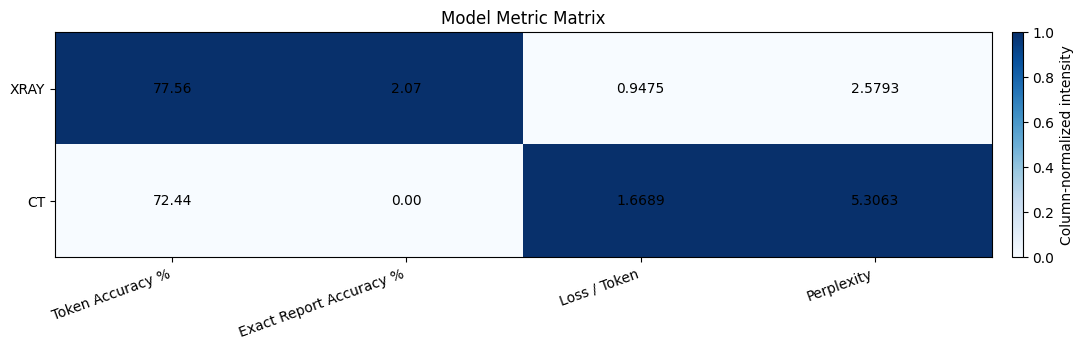

In [11]:
matrix_df = pd.DataFrame(
    {
        'Token Accuracy %': metrics_df['token_accuracy'] * 100,
        'Exact Report Accuracy %': metrics_df['exact_sequence_accuracy'] * 100,
        'Loss / Token': metrics_df['validation_loss'],
        'Perplexity': metrics_df['perplexity'],
    }
)

values = matrix_df.to_numpy(dtype=float)
col_min = values.min(axis=0)
col_max = values.max(axis=0)
normalized = (values - col_min) / np.where(col_max - col_min == 0, 1, col_max - col_min)

fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(normalized, cmap='Blues', aspect='auto')

ax.set_xticks(np.arange(matrix_df.shape[1]))
ax.set_xticklabels(matrix_df.columns, rotation=20, ha='right')
ax.set_yticks(np.arange(matrix_df.shape[0]))
ax.set_yticklabels(matrix_df.index)
ax.set_title('Model Metric Matrix')

for row in range(matrix_df.shape[0]):
    for col in range(matrix_df.shape[1]):
        value = matrix_df.iloc[row, col]
        label = f'{value:.2f}' if 'Accuracy' in matrix_df.columns[col] else f'{value:.4f}'
        ax.text(col, row, label, ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='Column-normalized intensity')
plt.tight_layout()
plt.show()

## 10. Token Outcome Matrix

This matrix shows correct versus incorrect next-token predictions for each model.

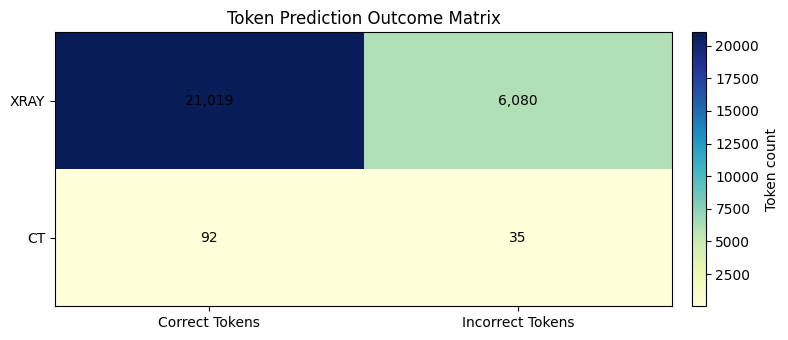

,Correct Tokens,Incorrect Tokens
XRAY,21019,6080
CT,92,35


In [12]:
token_matrix = pd.DataFrame(
    {
        'Correct Tokens': metrics_df['correct_tokens'],
        'Incorrect Tokens': metrics_df['total_tokens'] - metrics_df['correct_tokens'],
    }
).astype(int)

fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(token_matrix.to_numpy(), cmap='YlGnBu', aspect='auto')

ax.set_xticks(np.arange(token_matrix.shape[1]))
ax.set_xticklabels(token_matrix.columns)
ax.set_yticks(np.arange(token_matrix.shape[0]))
ax.set_yticklabels(token_matrix.index)
ax.set_title('Token Prediction Outcome Matrix')

for row in range(token_matrix.shape[0]):
    for col in range(token_matrix.shape[1]):
        ax.text(col, row, f'{token_matrix.iloc[row, col]:,}', ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03, label='Token count')
plt.tight_layout()
plt.show()

display(token_matrix)